In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

fund = pd.read_csv("../data/processed/01_fund_master.csv")

txn = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

hold = pd.read_csv(
    "../data/processed/09_portfolio_holdings.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

print("Data Loaded Successfully")

Data Loaded Successfully


In [4]:
import os

os.makedirs(
    "../reports",
    exist_ok=True
)

print("Reports folder ready")

Reports folder ready


In [5]:
results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    returns = temp["nav"].pct_change().dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    results.append([
        code,
        var95,
        cvar95
    ])

var_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


### Advanced Insight 1

Funds with higher VaR and CVaR values exhibit greater downside risk during adverse market conditions.

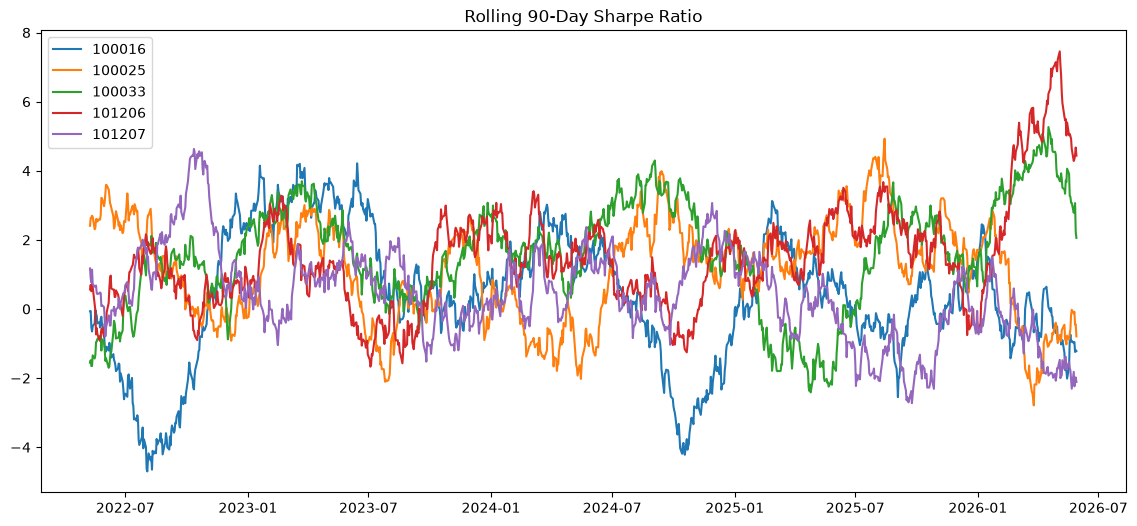

In [6]:
sample_codes = nav[
    "amfi_code"
].unique()[:5]

plt.figure(figsize=(14,6))

for code in sample_codes:

    temp = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    returns = temp["nav"].pct_change()

    sharpe = (
        returns.rolling(90).mean()
        /
        returns.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        sharpe,
        label=str(code)
    )

plt.legend()

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

### Advanced Insight 2

Funds maintaining higher rolling Sharpe ratios generated superior risk-adjusted returns.

In [7]:
txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

first_txn = txn.groupby(
    "investor_id"
)["transaction_date"].min()

cohort = first_txn.dt.year

txn["cohort_year"] = txn[
    "investor_id"
].map(cohort)

cohort_summary = txn.groupby(
    "cohort_year"
).agg({
    "amount_inr":["mean","sum"]
})

cohort_summary

amount_inr            
                      mean         sum
cohort_year                           
2024         107422.541832  3491125187
2025         109158.577061    30455243

### Advanced Insight 3

Recent investor cohorts contributed higher average investment amounts than earlier cohorts.

In [8]:
sip = txn[
    txn["transaction_type"] == "Sip"
]

sip = sip.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)

sip["gap"] = sip.groupby(
    "investor_id"
)["transaction_date"].diff().dt.days

risk = sip.groupby(
    "investor_id"
)["gap"].mean()

at_risk = risk[
    risk > 35
]

print(
    "At Risk Investors:",
    len(at_risk)
)

At Risk Investors: 3825


### Advanced Insight 4

Investors with average SIP gaps greater than 35 days are at risk of discontinuing their investment plans.

In [9]:
hold["weight_sq"] = (
    hold["weight_pct"] / 100
) ** 2

hhi = hold.groupby(
    "amfi_code"
)["weight_sq"].sum()

hhi = hhi.reset_index()

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


### Advanced Insight 5

Funds with higher HHI values maintain concentrated portfolios and carry higher concentration risk.